Colab Download

In [1]:
!pip install kagglehub

Download Dataset

In [2]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/face-mask-detection")
print(path)

Using Colab cache for faster access to the 'face-mask-detection' dataset.
/kaggle/input/face-mask-detection


Preprocessing

In [3]:
import os
import cv2
import numpy as np
import xml.etree.ElementTree as ET

image_dir = path + "/images"
annotation_dir = path + "/annotations"

data = []
labels = []

Extract faces + labels from XML

In [4]:
for file in os.listdir(annotation_dir):
    tree = ET.parse(os.path.join(annotation_dir, file))
    root = tree.getroot()

    img_file = root.find('filename').text
    img_path = os.path.join(image_dir, img_file)

    image = cv2.imread(img_path)

    for obj in root.findall('object'):
        label = obj.find('name').text

        if label not in ["with_mask", "without_mask"]:
            continue

        bbox = obj.find('bndbox')
        x1 = int(bbox.find('xmin').text)
        y1 = int(bbox.find('ymin').text)
        x2 = int(bbox.find('xmax').text)
        y2 = int(bbox.find('ymax').text)

        face = image[y1:y2, x1:x2]
        face = cv2.resize(face, (128, 128))

        data.append(face)
        labels.append(0 if label == "with_mask" else 1)

Normalize

In [5]:
X = np.array(data) / 255.0
y = np.array(labels)

Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

CNN Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.9098 - loss: 0.2253 - val_accuracy: 0.9715 - val_loss: 0.0963
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9533 - loss: 0.1355 - val_accuracy: 0.9731 - val_loss: 0.0762
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9616 - loss: 0.1105 - val_accuracy: 0.9589 - val_loss: 0.0983
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9640 - loss: 0.1178 - val_accuracy: 0.9541 - val_loss: 0.1330
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9620 - loss: 0.1104 - val_accuracy: 0.9652 - val_loss: 0.0943
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9608 - loss: 0.1122 - val_accuracy: 0.9699 - val_loss: 0.0875
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9676 - loss: 0.0923 - val_accuracy: 0.9763 - val_loss: 0.0724
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9679 - loss: 0.0816 - val_accuracy: 0.9604 - val_l

Graph

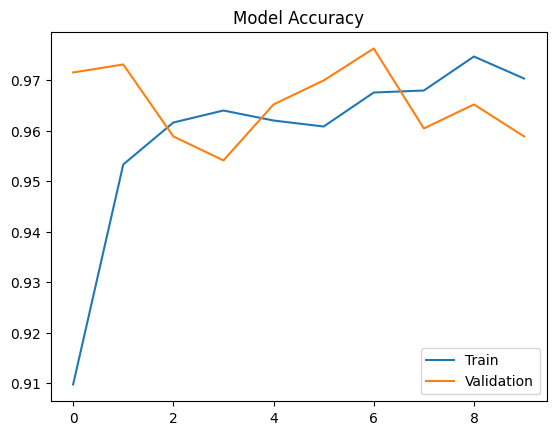

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

Evaluation

In [11]:
from sklearn.metrics import classification_report

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       637
           1       0.90      0.98      0.94       153

    accuracy                           0.98       790
   macro avg       0.95      0.98      0.96       790
weighted avg       0.98      0.98      0.98       790



Saving the model

In [13]:
model.save("face_mask_model.h5")